# Processing glacier seismic data with HVSRpy


### Authors:
* Koen Van Noten ([@KoenVanNoten](https://github.com/KoenVanNoten))
* Thomas Lecocq ([@seismotom](https://github.com/ThomasLecocq))

### Introduction:
Three-component __seismic nodes__ are conquering the world these days as lightweight smart seismic sensors. This notebook provides a guideline how to handle seismic node data and perform H/V spectral ratio analysis of ambient noise (mHVSR of HVSRN) recorded with seismic nodes. We'll show you some methods:
* how to perform mHVSR using hvsrpy
* how to split data and compute hourly hvsr 

### hvsrpy License Information
This notebook uses  _hvsrpy_, a Python package for horizontal-to-vertical spectral ratio processing. _hvsrpy_ is an open-source Python package for performing horizontal-to-vertical spectral ratio (HVSR) processing of microtremor and earthquake recordings.

    Copyright (C) 2019-2025 Joseph P. Vantassel (joseph.p.vantassel@gmail.com)

    This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.|

    This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General Public License for more details. You should have received a copy of the GNU General Public License along with this program.  If not, see <https: //www.gnu.org/licenses/>.
    
https://hvsrpy.readthedocs.io/en/latest/index.html

### Citation

If you use _hvsrpy_ in your research or consulting, we ask you please cite the following:

> Vantassel, J.P. (2025). "_hvsrpy_: An Open‐Source Python Package for Microtremor
> and Earthquake Horizontal‐to‐Vertical Spectral Ratio Processing". Seismological
> Research Letters. 96 (4): 2671–2682,
> [https://doi.org/10.1785/0220240395](https://doi.org/10.1785/0220240395)

The essential codes to analyse the output data in this notebook are based on the following paper:
> Van Noten, K., Lecocq, T., Goffin, C., Meyvis, B., Molron, J., Debacker, T.N. & Devleeschouwer, X. 2022. Brussels’ 
> bedrock paleorelief from borehole-controlled powerlaws linking polarised H/V resonance frequencies and sediment 
> thickness. _Journal of Seismology_ 26, 35-55. 
> https://doi.org/10.1007/s10950-021-10039-8  > https://publi2-as.oma.be/record/5626/files/2022_VanNotenetal_HVSR_Powerlaw_Brussels.pdf 

The code results from:
> Van Noten, K, Lecocq, Buddha Power, B. (2020). HVSR to Virtual Borehole (1.0). Zenodo.
> https://doi.org/10.5281/zenodo.4276310

In [1]:
import hvsrpy
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib.colors as colors
from obspy import UTCDateTime, read, Stream
from HVSR_minionology import *

# use ipython notebook in a wider screen
from IPython.display import display, HTML
display(HTML("<style>.jp-Notebook{max-width:100%!important}.container{width:95%!important}#notebook-container{width:95%!important}</style>"))

################ some hvsrpy definitions

def preprocessing(detrend, window_length, degrees_from_north, filter_corner_frequencies_in_hz, ignore_dissimilar_time_step_warning):
    preprocessing_settings = hvsrpy.settings.HvsrPreProcessingSettings()
    preprocessing_settings.detrend = detrend
    preprocessing_settings.window_length_in_seconds = window_length
    preprocessing_settings.orient_to_degrees_from_north = degrees_from_north
    preprocessing_settings.filter_corner_frequencies_in_hz = filter_corner_frequencies_in_hz
    preprocessing_settings.ignore_dissimilar_time_step_warning = ignore_dissimilar_time_step_warning

    #preprocessing_settings.psummary()

    return preprocessing_settings

def processing(HVSR, window_type, window_width, smoothing_operator, smoothing_bandwidth, freq_min, freq_max, steps, method_to_combine_horizontals, handle_dissimilar_time_steps_by, azimuth_steps = 10):
    if HVSR == 'traditional':
        processing_settings = hvsrpy.settings.HvsrTraditionalProcessingSettings()
    elif HVSR == 'azimuthal':
        processing_settings = hvsrpy.settings.HvsrAzimuthalProcessingSettings()
        processing_settings.azimuths_in_degrees = np.arange(0, 180, azimuth_steps)
    processing_settings.window_type_and_width = (window_type, window_width)
    processing_settings.smoothing=dict(operator=smoothing_operator,
                                       bandwidth=smoothing_bandwidth,
                                       center_frequencies_in_hz=np.geomspace(freq_min, freq_max, steps))
    processing_settings.method_to_combine_horizontals = method_to_combine_horizontals
    processing_settings.handle_dissimilar_time_steps_by = handle_dissimilar_time_steps_by
    #processing_settings.psummary()
    
    return processing_settings

## Notebook 20: ONE STATION / ONE DAY

Let's exploring the hvsrpy functionalities based on the recording of one station. We will use a cityseismometer first to understand dependancies, and then move to cryoseismology. 

## DATA SELECTION AND OUTPUT
Data from the cityseismometer comes from the Brussels surface station, UCCS, BE network.

Data comes from seismic data gathered from the Grenzgletscher, Switserland, in the Monta Rosa Massif. Data is property of Joachim Wasserman (LMU).  

<img src="Grenz_stations.jpg" width=1200></img>

In [2]:
## add full data path where your SDS is stored
DATA_PATH = '/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/'

# create data and output paths
output_folder = os.path.join(DATA_PATH, 'Analysed') 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
print('DATA_PATH: ',DATA_PATH)
print('OUTPUT   : ', output_folder)

DATA_PATH:  /Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/
OUTPUT   :  /Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed


In [3]:
### start with an easy case: a city seismometer in Brussels, Belgium
SDS = 'SDS'
network = 'BE'
year = '2024'
station = 'UCCS'
day = '080' # select a day: 079, 080, 081, 082

### Let's go cryoseismology
### choose station: ADR1, BB01, C16, C17, C29, C2A, C65, C66, C67, C68, C69, C6A, S35, UP1, UP2, UP3, UP4, UP5, UP6
#SDS = 'SDS'
#network = 'XG'
#year = '2024'
#station = 'C16'
#day = '080' # select a day, four days are available 079, 080, 081, 082

## check all data
file = os.path.join(DATA_PATH, SDS, year, network, station, '*.D', '*.%s'%day)
fnames = [[file]]
fnames

[['/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/SDS/2024/BE/UCCS/*.D/*.080']]

## A. Traditional HVSR
### HVSR Preprocessing Settings
- **Detrending**: `constant` - Remove mean from time series
- **Window Length**: `120` seconds - Duration of each time window for analysis
- **Orientation**: `None` - No rotation of horizontal components
- **Filter Corner Frequencies**: `(None, None)` Hz - No bandpass filtering applied
- **Ignore Time Step Warning**: `False` - Warnings enabled for dissimilar sampling rates

### HVSR Windowing - Smoothing - Freq domain Settings
- **Window Type**: `tukey` - Tapered cosine window
- **Window Width**: `0.05` - Taper fraction (5% of window at each end)
- **Smoothing Operator**: `konno_and_ohmachi` - Logarithmic smoothing
- **Smoothing Bandwidth**: `40` - Smoothing parameter (higher = more smoothing)
- **Minimum Frequency**: `1` Hz - Choose
- **Maximum Frequency**: `100` Hz - Choose
- **Number of Steps**: `1000` - Frequency resolution points

### HVSR Processing Methods
- **Horizontal Combination Method**: `geometric_mean` - Combine NS and EW components using geometric mean
- **Time Step Handling**: `frequency_domain_resampling` - Resample in frequency domain if sampling rates differ

In [4]:
### Preprocessing Settings
detrend = "constant"
window_length = 120
orient_to_degrees_from_north = None
filter_corner_frequencies_in_hz = (None, None)
ignore_dissimilar_time_step_warning = False

preprocessing_settings = preprocessing(detrend, window_length, orient_to_degrees_from_north, filter_corner_frequencies_in_hz, ignore_dissimilar_time_step_warning)

# Processing settings
window_type = "tukey"
window_width = 0.05
smoothing_operator = "konno_and_ohmachi"
smoothing_bandwidth = 40 # change this to see the smoothing effect
freq_min = 0.2 
freq_max = 50
steps = 200 #important param to choose the smoothness of your HVSR curve
method_to_combine_horizontals = "geometric_mean"
handle_dissimilar_time_steps_by = "frequency_domain_resampling"

processing_settings = processing('traditional', window_type, window_width, smoothing_operator, smoothing_bandwidth, freq_min, freq_max, steps, method_to_combine_horizontals, handle_dissimilar_time_steps_by)

### Processing Steps

1. **Read Seismic Data** using `hvsrpy.read()`. Creates `srecords` object containing raw sensor records
2. **Preprocess Data** applying preprocessing settings (detrending, windowing, filtering). Creates `srecords_preprocessed` ready for HVSR analysis.
3. **Compute HVSR** and apply smoothing and frequency domain processing. Generates `hvsr` object containing all HVSR curves and statistics
4. **Display Statistics Summary** (mean, standard deviation) Summarize valid window counts


### `HVSR` object contains
- Individual HVSR curves for each time window
- Peak frequency and amplitude statistics
- Valid/rejected window information
- Lognormal distribution parameters for peak characteristics

In [5]:
srecords = hvsrpy.read(fnames, verbose = True)
srecords_preprocessed = hvsrpy.preprocess(srecords, preprocessing_settings)
hvsr = hvsrpy.process(srecords_preprocessed, processing_settings)

In [6]:
# explore the hvsr object
#hvsr
#hvsrpy.object_io.write_hvsr_object_to_file(hvsr, 'test.csv')

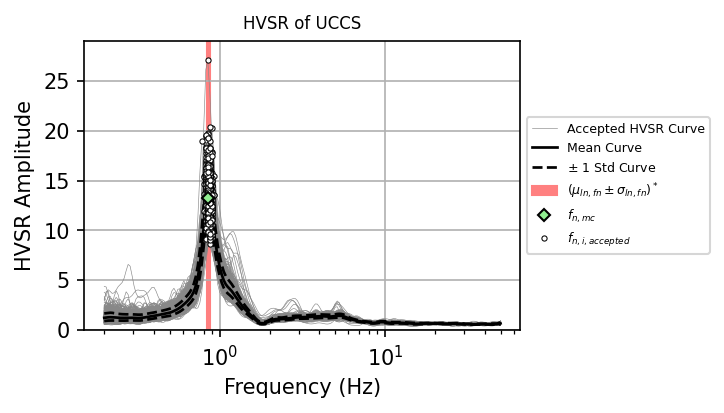

In [7]:
(fig, ax) = hvsrpy.plot_single_panel_hvsr_curves(hvsr,)
### it's python, so you can do whatever you want to improve the plot
ax.get_legend().remove()
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize = 6)
plt.grid()
plt.title('HVSR of %s'%station, fontsize = 8)
plt.show()

### Window Rejection Methods
We can reject windows using several methods. This method will compare all data versus the window rejection data. hvsrpy reads the data again, applies a correction (=PREPROCESSING) and computes hvsr again. Choose one of the following rejection algorithms to filter noisy HVSR windows:

0. no rejection - Process all windows without filtering. BEFORE REJECTION and AFTER REJECTION will be similar.
1. **Cox et al. (2020)** | Frequency-Domain Window Rejection Algorithm  https://academic.oup.com/gji/article/221/3/2170/5805192
    - `n=2` (std deviations), `search_range=(1, 100)` Hz
    - n controls the width of the acceptable range for rejection. When⁠ n=1 or n=2, the f0 from any window i has a probability of 68.3% or 95.5% of being retained in the computations. 
    - A small value of n will reject more windows 
    - Rejects windows with anomalous spectral peaks outside statistical bounds
2. **STA-LTA** | Short term average - Long term average rejection algorithm = 'STA-LTA'
    - Detects transient signals in time domain
    - Rejects windows with sudden amplitude spikes
    - `sta-lta params` needed
3. **Max Value** | Maximum value window rejection = Max_Value
    - Threshold: `0.5` (amplitude limit in percentage)
    - Rejects windows exceeding maximum acceleration value
    - Filters out clipped or saturated signals

In [8]:
#Choose the filter FALSE = no filter - TRUE = filter

rejection_filter = False 
#rejection_filter = True 

############################ 1. Cox et al. (2020) | Frequency-Domain Window Rejection Algorithm
rejection_method = 'cox'
n = 2
freq_min, freq_max = freq_min, freq_max #adapt if you want to filter in a more narrow freq band, e.g. 1, 10
#freq_min, freq_max = 0.1, 0.4

############################ 2. STA-LTA | Short term average - Long term average rejection algorithm
# rejection_method = 'sta-lta'
sta_seconds=20
lta_seconds=120
min_sta_lta_ratio=0.2
max_sta_lta_ratio=2.5

############################ 3. Max Value | Maximum value window rejection
rejection_method = 'maxvalue'
maximum_value_threshold = 0.3 

,Exponentitated Lognormal Median (units),Lognormal Standard Deviation (log units),-1 Lognormal Standard Deviation (units),+1 Lognormal Standard Deviation (units)
"Resonant Site Frequency, fn (Hz)",0.853,0.023,0.833,0.873
"Resonant Site Period, Tn (s)",1.172,0.023,1.200,1.146
"Resonance Amplitude, An",13.628,0.146,11.779,15.768


------------------------------------------------------------
mean_f0_freq from windows: 0.853 Hz
mean_f0_amp from windows: 13.628 Hz
mean_f0_freq from mean curve: 0.847 Hz
mean_f0_amp from mean curve: 13.225 Hz
std_f0_freq: 0.023 Hz
f0_freq_minus_1std: 0.873 Hz
f0_freq_plus_1std: 0.833 Hz
Without window rejection: 719 windows
      


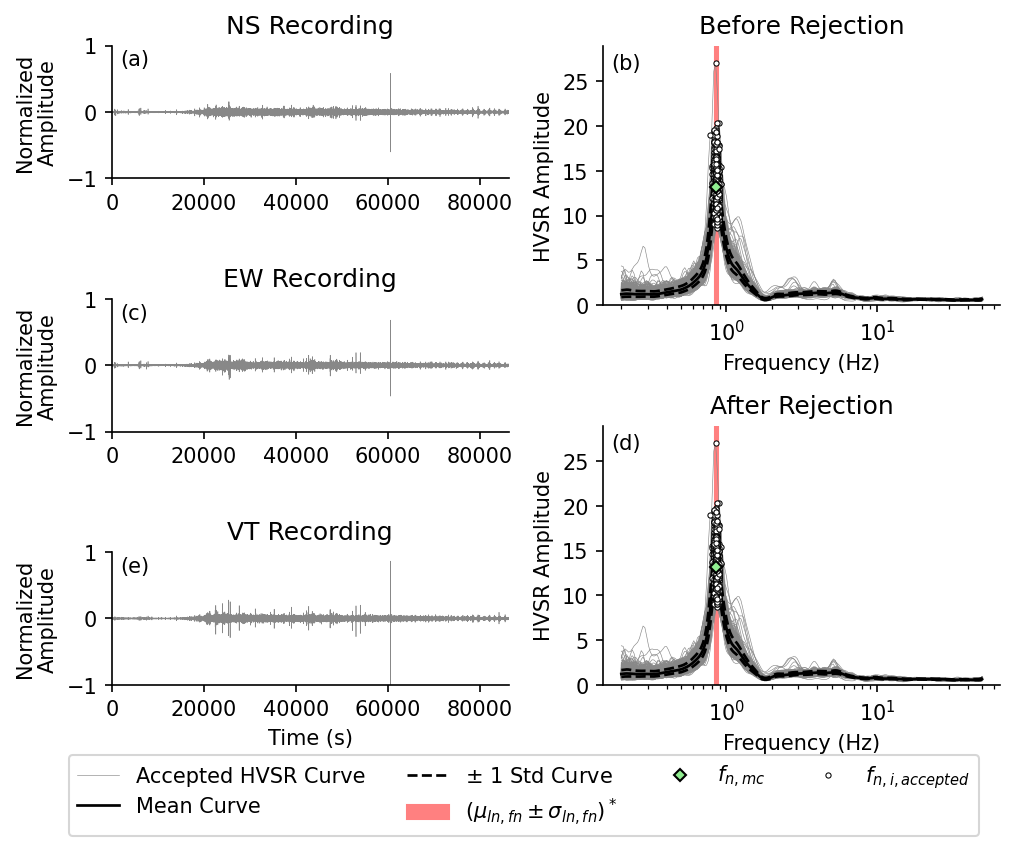

In [9]:
############################################## GO
if rejection_filter:
    if rejection_method == 'Cox':
        n = n
        search_range_in_hz = (freq_min, freq_max) #adapt to your preference
        _ = hvsrpy.frequency_domain_window_rejection(hvsr, n=n, search_range_in_hz=search_range_in_hz)
    elif rejection_method =="sta-lta":
        srecords = hvsrpy.read(fnames)
        srecords_preprocessed = hvsrpy.preprocess(srecords, preprocessing_settings)
        _ = hvsrpy.sta_lta_window_rejection(srecords_preprocessed, sta_seconds=sta_seconds, 
                                            lta_seconds=lta_seconds, min_sta_lta_ratio=min_sta_lta_ratio, max_sta_lta_ratio=max_sta_lta_ratio,hvsr=hvsr)
    elif rejection_method == 'maxvalue':
        srecords = hvsrpy.read(fnames)
        maximum_value_threshold = maximum_value_threshold
        srecords_preprocessed = hvsrpy.preprocess(srecords, preprocessing_settings)
        _ = hvsrpy.maximum_value_window_rejection(srecords_preprocessed, hvsr=hvsr, maximum_value_threshold = maximum_value_threshold)

hvsrpy.summarize_hvsr_statistics(hvsr)

### read the stats
mean_f0_freq = hvsr.mean_fn_frequency(distribution='lognormal')
mean_f0_amp = hvsr.mean_fn_amplitude(distribution='lognormal')
std_f0_freq = hvsr.std_fn_frequency(distribution='lognormal')
std_f0_freq_max = hvsr.nth_std_fn_frequency(1, distribution='lognormal')
std_f0_freq_min = hvsr.nth_std_fn_frequency(-1, distribution='lognormal')
f_mc, a_mc = hvsr.mean_curve_peak(distribution='lognormal')

# Get number of windows from the amplitude array shape
n_windows = hvsr.amplitude.shape[0]
        
print(60*'-')
print(f"mean_f0_freq from windows: {mean_f0_freq:.3f} Hz")
print(f"mean_f0_amp from windows: {mean_f0_amp:.3f} Hz")
print(f"mean_f0_freq from mean curve: {f_mc:.3f} Hz")
print(f"mean_f0_amp from mean curve: {a_mc:.3f} Hz")

print(f"std_f0_freq: {std_f0_freq:.3f} Hz")
print(f"f0_freq_minus_1std: {std_f0_freq_max:.3f} Hz")
print(f"f0_freq_plus_1std: {std_f0_freq_min:.3f} Hz")
print(f"Without window rejection: {n_windows} windows")
if rejection_filter:
    n_valid_after = hvsr.valid_window_boolean_mask.sum()
    print(f"With window rejection: {n_valid_after}/{hvsr.n_curves}")
print('      ')

### SHOW DATA
%matplotlib inline
fig, axs = hvsrpy.plot_pre_and_post_rejection(srecords_preprocessed, hvsr)
plt.show()

## Virtual Borehole Generation from HVSR

- **Project Name**: `Grenzgletscher`
- **Station ID**: Defined from `station` variable
- **Surface Elevation**: Reference height for depth calculations
- **Auto Amplitude**: `True` - Automatically scale amplitude axis
- **Manual Amplitude**: `20` - Override value (used if auto_amplitude= `False`)
- **Display Range**: `[10, 100]` Hz - Frequency bounds for visualization

### Depth Conversion Method

- **Fixed shear-wave velocity** if selected method = `'Vs'`
    - Shear-wave Velocity (Vs): choose e.g. `1900` m/s
    - Depth calculated using: `depth = Vs / (4 × f0)`

- **Power Law** method = 'powerlaw': 
    - `depth = a × f0^b`
  - a_pw = 88.631 (Regional relation for Brussels, Van Noten et al. 2022), find your own by doing HVSR above boreholes
  - b_pw = -1.683
### Virtual Borehole Generation  
- Visual representation of subsurface impedance contrasts converted to depth
- **Function**: `HV_to_virtual_borehole()`
- **Parameters**:
    - Input `HV file` 
    - Station ID and surface elevation (Z)
    - Peak detection method: `'f0_avg'` - Mean curve-based peak picking (also 'f0_win' from windows possible)

In [10]:
## export the hvsrpy to a classic Geopsy .hv output
outfile = os.path.join(DATA_PATH, output_folder, '%s.%s.hv'%(station, day))
hvsrpy_export_to_geopsy_hv(hvsr, outfile)

Exported to /Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed/UCCS.080.hv


/Users/eibl/Documents/Daten/Dokumente/Professur/7_Lehre/8_ObservationalSeismology/JupyterNotebooks/2026/DATA/Analysed/UCCS.080.hv
A0: 13.22 fmax:  0.85
0.8465 0.852928 0.019533000000000023 13.6282 719.0 719.0 0.833395 0.872918
Z:  102
bedrock at -10.2  m (range:  -12.9 m,  -7.7 m)


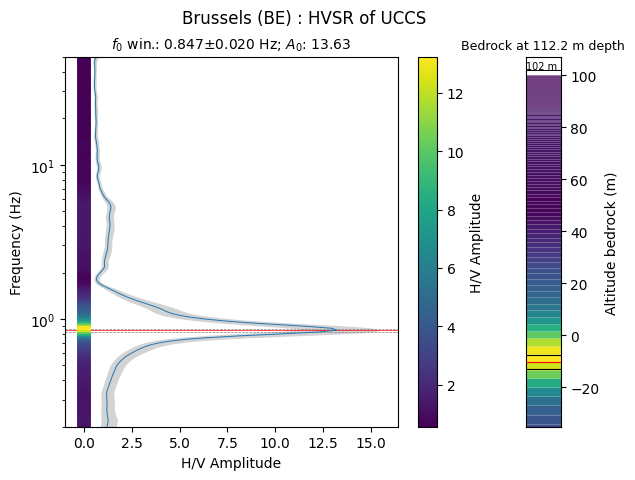

In [11]:
Project = 'Brussels (BE)'
Z = 102

### cryseismology
#Project = 'Grenzgletscher'
#Z = 2549.345  #surface height fo BB01

ID = station

# Choose if the amplitude on the frequency-amplitude plot needs to be selected automatically or manually
auto_amplitude = True
manual_amplitude = 20

# Choose between which frequencies you want to plot. Default = between 0.5 Hz and 50 Hz, or overwrite with [0.2, 100]
freq = [freq_min, freq_max]

## f0 needs to be converted to depth by: 

## 1. by using a Powerlaw relation between resonance frequency and depth according to the formula: depth = a * power(f0, b)
## a & b values of the Regional powerlaw relation (R') of Van Noten et al. 2022. (applicable for Brussels)
#depth_conversion = 'powerlaw'
a_pw = 88.631     # a value
b_pw = -1.683    # b value

## or by using a fixed velocity
depth_conversion = 'Vs'
Vs = 380 # m/s #Brussels subsurface
#Vs = 1600 # m/s #Blue ice velocity

#virtual borehole
distance_above_surface = 5
distance_below_bedrock = 25 

###################################################################
HV_file = outfile
print(HV_file)
if depth_conversion == 'powerlaw':
    HV_to_virtual_borehole(HV_file, ID, Z, 'f0_avg', Project, distance_below_bedrock, distance_above_surface, depth_conversion, 
                           a_pw = a_pw, b_pw=b_pw, auto_amplitude=auto_amplitude, manual_amplitude=manual_amplitude, freq = freq)
if depth_conversion == 'Vs':
    HV_to_virtual_borehole(HV_file, ID, Z, 'f0_avg', Project, distance_below_bedrock, distance_above_surface, depth_conversion, 
                           Vs=Vs, auto_amplitude=auto_amplitude, manual_amplitude=manual_amplitude, freq = freq)
#save it by node name
#savefile = os.path.join(data_folder, '%s_Virtual_Borehole.png'%ID)
#plt.savefig(savefile, format= 'png', dpi = 300)

## B. Azimuthal dependancy of the HVSR
In previous steps we computed the HVSR of mean |E + H| / V. For the azimuthal HVSR, an HVSR curve is computed for each 5°. This is a more timeconsuming approach, but let you deduce the direction in which the f0 is maximal and minimal.

In [12]:
### Preprocessing Settings
detrend = "constant"
window_length = 120
orient_to_degrees_from_north = None
filter_corner_frequencies_in_hz = (None, None)
ignore_dissimilar_time_step_warning = False

preprocessing_settings = preprocessing(detrend, window_length, orient_to_degrees_from_north, filter_corner_frequencies_in_hz, ignore_dissimilar_time_step_warning)

# Processing settings
window_type = "tukey"
window_width = 0.05
smoothing_operator = "konno_and_ohmachi"
smoothing_bandwidth = 40
freq_min = 0.2
freq_max = 50
steps = 200 #important param to choose the smoothness of your HVSR curve
method_to_combine_horizontals = "geometric_mean"
handle_dissimilar_time_steps_by = "frequency_domain_resampling"

azimuthal_steps = 10 ### these are the rotation steps for which the HVSR is computed

processing_settings = processing('azimuthal', window_type, window_width, smoothing_operator, 
                                 smoothing_bandwidth, freq_min, freq_max, steps, method_to_combine_horizontals, 
                                 handle_dissimilar_time_steps_by, azimuthal_steps)

In [13]:
srecords = hvsrpy.read(fnames)
srecords = hvsrpy.preprocess(srecords, preprocessing_settings)
# Let's define a new obsject hvsr_rot, so it doesnt overwrite the traditional hvsr object 
hvsr_rot = hvsrpy.process(srecords, processing_settings)

### Explore and plot results

In [14]:
all_peak_freqs, all_peak_A0s, all_azimuths = [],[],[]

for h, a in zip(hvsr_rot.hvsrs, hvsr_rot.azimuths):
    mean_f0_freq = h.mean_fn_frequency()
    mean_f0_amp = h.mean_fn_amplitude()
    all_azimuths.append(a)
    all_peak_freqs.append(mean_f0_freq)
    all_peak_A0s.append(mean_f0_amp)
max_A0 = np.max(all_peak_A0s)
max_A0_idx = np.argmax(all_peak_A0s)
max_f0 = all_peak_freqs[max_A0_idx]
max_azi = all_azimuths[max_A0_idx]
min_A0 = np.min(all_peak_A0s)
min_A0_idx = np.argmin(all_peak_A0s)
min_f0 = all_peak_freqs[min_A0_idx]
min_azi = all_azimuths[min_A0_idx]

print(f"Max f0: {max_f0:.4f} Hz  @ azimuth {max_azi:.0f}° with H/V amplitude of {max_A0:.2f}")
print(f"Min f0: {min_f0:.4f} Hz  @ azimuth {min_azi:.0f}° with H/V amplitude of {min_A0:.2f}")

# Per-azimuth stats
print('---------')
print(f"{'Azimuth':>0} {'mean f0 (Hz)':>4} {'mean Amp':>8}")
for azi, f, a in zip(all_azimuths, all_peak_freqs, all_peak_A0s):
    print(f"{int(azi):>1.0f} "
          f"{f:>11.4f} "
          f"{a:>10.4f} ")

Max f0: 0.8464 Hz  @ azimuth 10° with H/V amplitude of 17.51
Min f0: 0.8632 Hz  @ azimuth 100° with H/V amplitude of 12.43
---------
Azimuth mean f0 (Hz) mean Amp
0      0.8476    17.3109 
10      0.8464    17.5084 
20      0.8462    17.4436 
30      0.8460    17.1164 
40      0.8467    16.5506 
50      0.8476    15.7864 
60      0.8492    14.9001 
70      0.8523    13.9987 
80      0.8557    13.2138 
90      0.8596    12.6614 
100      0.8632    12.4317 
110      0.8650    12.5604 
120      0.8643    13.0162 
130      0.8608    13.7079 
140      0.8566    14.5405 
150      0.8537    15.4052 
160      0.8514    16.2069 
170      0.8492    16.8618 


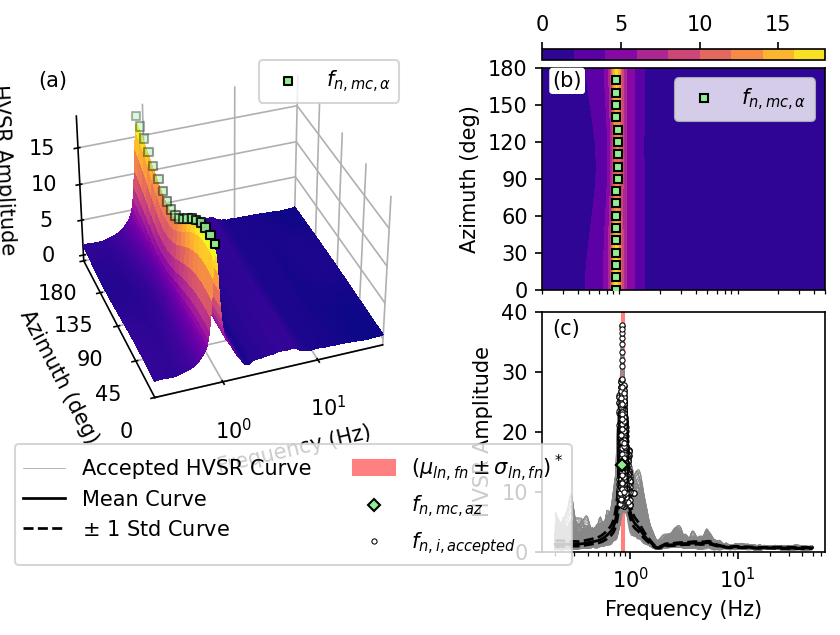

In [15]:
fig, axs = hvsrpy.plot_azimuthal_summary(hvsr_rot)
### it's python, so you can do whatever you want to improve the plot
fig.set_size_inches(7, 5) 
for ax in [a for row in axs for a in (row if hasattr(row, '__iter__') else [row])]:
    legend = ax.get_legend()
    if legend:
        legend.prop.set_size(7)
plt.show()